In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import DataLoader, Subset
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib
from sklearn.base import clone


In [2]:
import torch

# 检查是否有可用的 GPU
if torch.cuda.is_available():
    print("CUDA 可用，GPU 可用。")
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"当前设备名称: {torch.cuda.get_device_name(0)}")
    print(f"当前设备总内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA 不可用，仅支持 CPU。")


CUDA 可用，GPU 可用。
CUDA 版本: 12.1
GPU 数量: 1
当前设备名称: NVIDIA GeForce RTX 3080 Ti
当前设备总内存: 11.76 GB


In [3]:
import pandas as pd
from rdkit import Chem

In [4]:
data=pd.read_excel("./algae_EC10_unique.xlsx")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values

In [5]:
endpoint = data['endpoint']
mgperL=np.log1p(mgperL)

In [6]:
# 数据增强函数：简单的 SMILES 序列翻转
def augment_smiles(smiles):
    """简单的数据增强方法，例如旋转 SMILES 字符串"""
    if random.random() > 0.5:
        return smiles[::-1]  # 翻转字符串
    return smiles

# 根据 mgperL 浓度生成分类标签
def generate_labels(mgperL):
    """根据 mgperL 的浓度范围生成分类标签"""
    if mgperL < 0.2:
        return 0  # high
    elif 0.2 <= mgperL < 1.5:
        return 1  # mid
    elif 1.5 <= mgperL < 3.5:
        return 2  # mid
    else:
        return 3  # low

# 数据集定义
class SMILES_Dataset(Dataset):
    def __init__(self, smiles, reg_labels, class_labels):
        self.smiles = smiles
        self.reg_labels = reg_labels  # 回归任务标签 (mgperL)
        self.class_labels = class_labels  # 分类任务标签

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        #smiles = augment_smiles(self.smiles[idx])  # 数据增强
        smiles = self.smiles[idx]  # 数据增强
        reg_label = self.reg_labels[idx]
        class_label = self.class_labels[idx]
        tokens = tokenizer(smiles, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        return tokens, torch.tensor(reg_label, dtype=torch.float32), torch.tensor(class_label, dtype=torch.long)



class ChemBERTa_MultiTask(nn.Module):
    def __init__(self, num_classes):
        super(ChemBERTa_MultiTask, self).__init__()
        # 加载预训练的ChemBERTa模型
        self.chemberta = chemberta_model
        hidden_size = self.chemberta.config.hidden_size  # 一般为768
        # 回归任务的全连接层
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 1)
        )

        
        # 分类任务的全连接层
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 4)
        )


    def forward(self, tokens):
        output = self.chemberta(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]  # [CLS] token 嵌入
        reg_output = self.regressor(cls_embedding)  # 回归任务输出
        class_output = self.classifier(cls_embedding)  # 分类任务输出
        return reg_output, class_output

In [7]:
# 加载 ChemBERTa 模型和 tokenizer
model_name = "../models/chemBERTa"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
chemberta_model = RobertaModel.from_pretrained(model_name)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChemBERTa_MultiTask(chemberta_model).to(device)  
# 加载最佳模型
model.load_state_dict(torch.load('./ALGAE_EC10_MT_MODEL.pth'))

/root/miniconda3/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

In [8]:
# 提取 SMILES 的嵌入表示
def extract_embeddings(smiles_list, model, tokenizer, device):
    embeddings = []
    model.eval()  # 设置模型为评估模式
    with torch.no_grad():
        for smiles in smiles_list:
            # Tokenize the SMILES string
            tokens = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            
            # 通过 ChemBERTa 模型获得输出
            outputs = model.chemberta(**tokens)  # 提取 ChemBERTa 模型的输出
            
            # 提取 [CLS] token 的嵌入作为 SMILES 的整体嵌入
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # 获取多维的 [CLS] 嵌入
            embeddings.append(cls_embedding)
    
    return np.vstack(embeddings)  # 将所有嵌入拼接成一个矩阵

In [9]:
# 使用 PCA 对嵌入进行降维，同时获取主成分的解释方差百分比
def apply_pca(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(embeddings)
    explained_variance = pca.explained_variance_ratio_  # 获取每个主成分的解释方差
    return pca_result, explained_variance

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6), dpi=300)
    
    # 为 labels 只有 0 和 1 两个值指定两个颜色
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='coolwarm', alpha=0.9, s=4)

    plt.xlabel(f'PCA 1  {explained_variance[0]*100:.2f}% ', fontsize=20)
    plt.ylabel(f'PCA 2  {explained_variance[1]*100:.2f}% ', fontsize=20)

    # 添加图例，手动指定标签
    plt.legend(handles=scatter.legend_elements()[0], labels=['Label 0', 'Label 1'], loc='best', fontsize=17,frameon=False)
    
    # 获取当前坐标轴对象
    ax = plt.gca()

    # 设置所有边框的可见性，并确保框线颜色正常显示
    ax.spines['top'].set_visible(True)    # 显示顶部框线
    ax.spines['right'].set_visible(True)  # 显示右侧框线
    ax.spines['top'].set_color('black')   # 设置顶部框线颜色为黑色
    ax.spines['right'].set_color('black') # 设置右侧框线颜色为黑色
    ax.spines['top'].set_linewidth(1.5)   # 设置顶部框线的宽度
    ax.spines['right'].set_linewidth(1.5) # 设置右侧框线的宽度

    # 让其余边框可见（通常默认已可见）
    ax.spines['top'].set_visible(False)  # 隐藏左侧框线
    ax.spines['right'].set_visible(False)  # 隐藏底部框线
    
    ax.tick_params(axis='both', labelsize=15)  # 设置x轴和y轴刻度标签的字体大小为12

    plt.show()


# 使用 PCA 降维，并获取解释方差
#pca_result, explained_variance = apply_pca(smiles_embeddings, n_components=2)

# 绘制 PCA 图，并显示每个主成分的解释方差百分比
#plot_pca_with_variance(pca_result, labels, explained_variance)

In [10]:
# 可视化函数，同时显示解释方差百分比，并加粗字体
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6), dpi=300)
    
    # 为 labels 只有 0 和 1 两个值指定两个颜色
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='coolwarm', alpha=0.9, s=4)

    # 加粗字体并增大字号
    plt.xlabel(f'PCA 1  {explained_variance[0]*100:.2f}% ', fontsize=20, fontweight='bold')
    plt.ylabel(f'PCA 2  {explained_variance[1]*100:.2f}% ', fontsize=20, fontweight='bold')

    # 添加图例，手动指定标签
    legend = plt.legend(
        handles=scatter.legend_elements()[0], 
        labels=['Label 0', 'Label 1'], 
        loc='best', 
        fontsize=17,
        frameon=False
    )
    for text in legend.get_texts():
        text.set_fontweight('bold')  # 加粗图例文字

    # 获取当前坐标轴对象
    ax = plt.gca()

    # 设置所有边框的可见性，并确保框线颜色正常显示
    # 让其余边框可见（通常默认已可见）
    ax.spines['top'].set_visible(False)  # 隐藏左侧框线
    ax.spines['right'].set_visible(False)  # 隐藏底部框线
    ax.spines['top'].set_color('black')   
    ax.spines['right'].set_color('black') 
    ax.spines['top'].set_linewidth(1.5)   
    ax.spines['right'].set_linewidth(1.5) 

    # 让其余边框可见（通常默认已可见）
    ax.spines['bottom'].set_visible(True)  
    ax.spines['left'].set_visible(True)  
    ax.spines['bottom'].set_color('black')  
    ax.spines['left'].set_color('black')  
    ax.spines['bottom'].set_linewidth(1.5)  
    ax.spines['left'].set_linewidth(1.5)  

    # 加粗 x 轴和 y 轴的刻度
    ax.tick_params(axis='both', labelsize=15, width=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')  # 加粗刻度标签

    plt.show()

In [11]:
#plot_pca_with_variance(pca_result, labels, explained_variance)

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib import font_manager



# 使用 t-SNE 对嵌入进行降维，同时获取每个主成分的解释方差百分比
def apply_tsne(embeddings, n_components=2):
    tsne = TSNE(n_components=n_components, random_state=42)
    tsne_result = tsne.fit_transform(embeddings)
    return tsne_result

def plot_tsne_with_variance(tsne_result, labels):
    plt.figure(figsize=(8, 6), dpi=300)
    
    # 绘制散点图，使用 'coolwarm' colormap，labels 作为着色依据
    scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='coolwarm', alpha=0.9, s=8)

    # 添加图例，并加粗字体
    legend = plt.legend(
        handles=scatter.legend_elements()[0], 
        labels=['Label 0', 'Label 1'], 
        loc='best', 
        fontsize=18,
        frameon=False
    )
    for text in legend.get_texts():
        text.set_fontweight('bold')  # 加粗图例文本

    # 设置坐标轴标签，并加粗
    plt.xlabel('t-SNE 1', fontsize=20, fontweight='bold')
    plt.ylabel('t-SNE 2', fontsize=20, fontweight='bold')

    # 获取当前坐标轴对象
    ax = plt.gca()

    # 设置边框的可见性、颜色和加粗
    ax.spines['top'].set_visible(False)    
    ax.spines['right'].set_visible(False)  
    ax.spines['bottom'].set_visible(True)  
    ax.spines['left'].set_visible(True)  

    ax.spines['top'].set_color('black')   
    ax.spines['right'].set_color('black') 
    ax.spines['bottom'].set_color('black')  
    ax.spines['left'].set_color('black')  

    ax.spines['top'].set_linewidth(1.5)   
    ax.spines['right'].set_linewidth(1.5) 
    ax.spines['bottom'].set_linewidth(1.5)  
    ax.spines['left'].set_linewidth(1.5)  

    # 加粗 x 轴和 y 轴刻度
    ax.tick_params(axis='both', labelsize=15, width=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')  # 加粗刻度标签

    # 显示图形
    plt.show()



# # 使用 t-SNE 降维
# tsne_result = apply_tsne(smiles_embeddings, n_components=2)

# # 绘制 t-SNE 图
# plot_tsne_with_variance(tsne_result, labels)



In [13]:
# 提取嵌入
smiles_embeddings = extract_embeddings(smiles_data, model, tokenizer, device)

In [14]:
import xgboost as xgb

In [15]:
# 检查需要One-Hot编码的列，并进行编码（如果类别超过一种）
def encode_column(data, column_name):
    unique_values = data[column_name].unique()
    if len(unique_values) > 1:
        encoder = OneHotEncoder(sparse_output=False)
        return encoder.fit_transform(data[[column_name]])
    else:
        return None  # 只有一种类别时忽略

# 编码 effect、endpoint 和 species_group 列
effect_encoded = encode_column(data, 'effect')
endpoint_encoded = encode_column(data, 'endpoint')
species_encoded = encode_column(data, 'species_group')

# 将需要的列拼接成输入 X
X = np.hstack((smiles_embeddings, data['Duration_Value'].values.reshape(-1, 1)))

# 拼接编码后的列（如果存在）
for encoded_feature in [effect_encoded, endpoint_encoded, species_encoded]:
    if encoded_feature is not None:
        X = np.hstack((X, encoded_feature))

# 目标值 y
y = mgperL

In [16]:
import os

In [17]:
import joblib

In [18]:

# 2. 设置最佳超参数
best_params_xgb = {
    'n_estimators': 300,
    'subsample': 1.0,
    'max_depth': 3,
    'learning_rate': 0.05,
    'colsample_bytree': 0.6
}

# 3. 创建 XGBoost 模型
# 初始化并训练模型
xgb_model = XGBRegressor(n_jobs=-1, verbosity=0, **best_params_xgb)
xgb_model.fit(X, y)



model_path = os.path.join('Algae_chronic_xgb_single.json')
xgb_model.save_model(model_path)
print(f"💾 XGBoost 模型已保存至: {model_path}")

💾 XGBoost 模型已保存至: Algae_chronic_xgb_single.json


In [ ]:
#预测危险化合物

In [19]:
IECSC = pd.read_excel("../IECSC.xlsx")

In [20]:
IECSC_SMILES =  IECSC['SMILES'].tolist()

In [21]:
IECSC_smiles_embeddings = extract_embeddings(IECSC_SMILES, model, tokenizer, device)

In [22]:
# === 预测部分：固定 effect / duration（可选固定 endpoint/species），不重复定义类 ===
import os
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

# 路径配置（按需修改 NEW_EXCEL_PATH）
TRAIN_EXCEL_PATH = "./algae_EC10_unique.xlsx"   # 训练用表（用于拟合 OneHot）
NEW_EXCEL_PATH   = "./Hazard-chemical-list.xlsx"                                    # ←← 你的新 SMILES Excel
XGB_MODEL_PATH   = "./'Algae_chronic_xgb_single.json"
PRED_DIR         = "./predictions"
os.makedirs(PRED_DIR, exist_ok=True)



# 1) 基于训练表拟合 OneHot，并输出 effect / Duration 信息
train_df = pd.read_excel(TRAIN_EXCEL_PATH).dropna(subset=[
    "SMILES_Canonical_RDKit","Duration_Value","effect","endpoint","species_group"
])

print("🔎 effect 类别及计数：")
print(train_df["effect"].value_counts().to_string())

print("\n🔎 Duration_Value 统计：")
print(train_df["Duration_Value"].describe())


🔎 effect 类别及计数：
effect
POP    4407

🔎 Duration_Value 统计：
count     4407.000000
mean       144.394755
std        338.019597
min          0.000000
25%         72.000000
50%         72.000000
75%         96.000000
max      12960.000000
Name: Duration_Value, dtype: float64


In [23]:

enc_effect   = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train_df[["effect"]])
enc_endpoint = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train_df[["endpoint"]])
enc_species  = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train_df[["species_group"]])

EXTRA_DIM = 1 + enc_effect.categories_[0].size + enc_endpoint.categories_[0].size + enc_species.categories_[0].size



In [28]:
# ---------- 固定取值（在这里改） ----------
FIXED_EFFECT   = 'POP'           # 例如 "Mortality"；也可手动写字符串
FIXED_DURATION = float(72.0)  # 例如 48.0 或 96.0
FIXED_ENDPOINT = train_df["endpoint"].mode()[0]         # 例如 "EC10"
FIXED_SPECIES  = train_df["species_group"].mode()[0]    # 例如 "Invertebrates"

# ---------- 抽取 CLS768 ----------

emb_cls = IECSC_smiles_embeddings

# ---------- 构造额外特征（只对训练中“参与 one-hot 的列”编码；不足则右侧零填充到 EXTRA_DIM_CKPT） ----------
n = emb_cls.shape[0]
parts = []

# duration
dur = np.full((n, 1), FIXED_DURATION, dtype=np.float32)
parts.append(dur)

# # effect
# if enc_effect is not None:
#     eff = enc_effect.transform(pd.DataFrame({"effect": [FIXED_EFFECT]*n})).astype(np.float32)
#     parts.append(eff)

# # endpoint
# if enc_endpoint is not None:
#     endp = enc_endpoint.transform(pd.DataFrame({"endpoint": [FIXED_ENDPOINT]*n})).astype(np.float32)
#     parts.append(endp)

# # species
# if enc_species is not None:
#     spg = enc_species.transform(pd.DataFrame({"species_group": [FIXED_SPECIES]*n})).astype(np.float32)
#     parts.append(spg)

extra_now = np.hstack(parts) if parts else np.zeros((n, 0), dtype=np.float32)
extra_cols = extra_now.shape[1]

# # 右侧 pad 到 checkpoint 的 EXTRA_DIM
# if extra_cols < EXTRA_DIM_CKPT:
#     pad = np.zeros((n, EXTRA_DIM_CKPT - extra_cols), dtype=np.float32)
#     extra_now = np.hstack([extra_now, pad])
# elif extra_cols > EXTRA_DIM_CKPT:
#     # 理论上不会发生（我们只在“参与过”的列上编码）；出现则截断到训练维度
#     extra_now = extra_now[:, :EXTRA_DIM_CKPT]

# print(f"✅ 额外特征维度: 当前 {extra_now.shape[1]}，与 checkpoint {EXTRA_DIM_CKPT} 对齐")


In [31]:

# ---------- 拼接并预测 ----------
X_new = np.hstack([emb_cls, extra_now]).astype(np.float32)  # [N, 768 + EXTRA_DIM_CKPT]
y_log = xgb_model.predict(X_new).astype(np.float32)
y_mgL = np.expm1(y_log)

out = pd.DataFrame({
    "SMILES": IECSC_SMILES,
    "effect_fixed":   FIXED_EFFECT,
    "duration_fixed": FIXED_DURATION,
    "endpoint_fixed": FIXED_ENDPOINT,
    "species_fixed":  FIXED_SPECIES,
    "pred_log_mgperL": y_log,
    "pred_mgperL":     y_mgL,
})
save_path = os.path.join(PRED_DIR, "algae_EC10_REP_672.xlsx")
out.to_excel(save_path, index=False)
print(f"🎯 预测完成并保存：{save_path}")


🎯 预测完成并保存：./predictions/algae_EC10_REP_672.xlsx


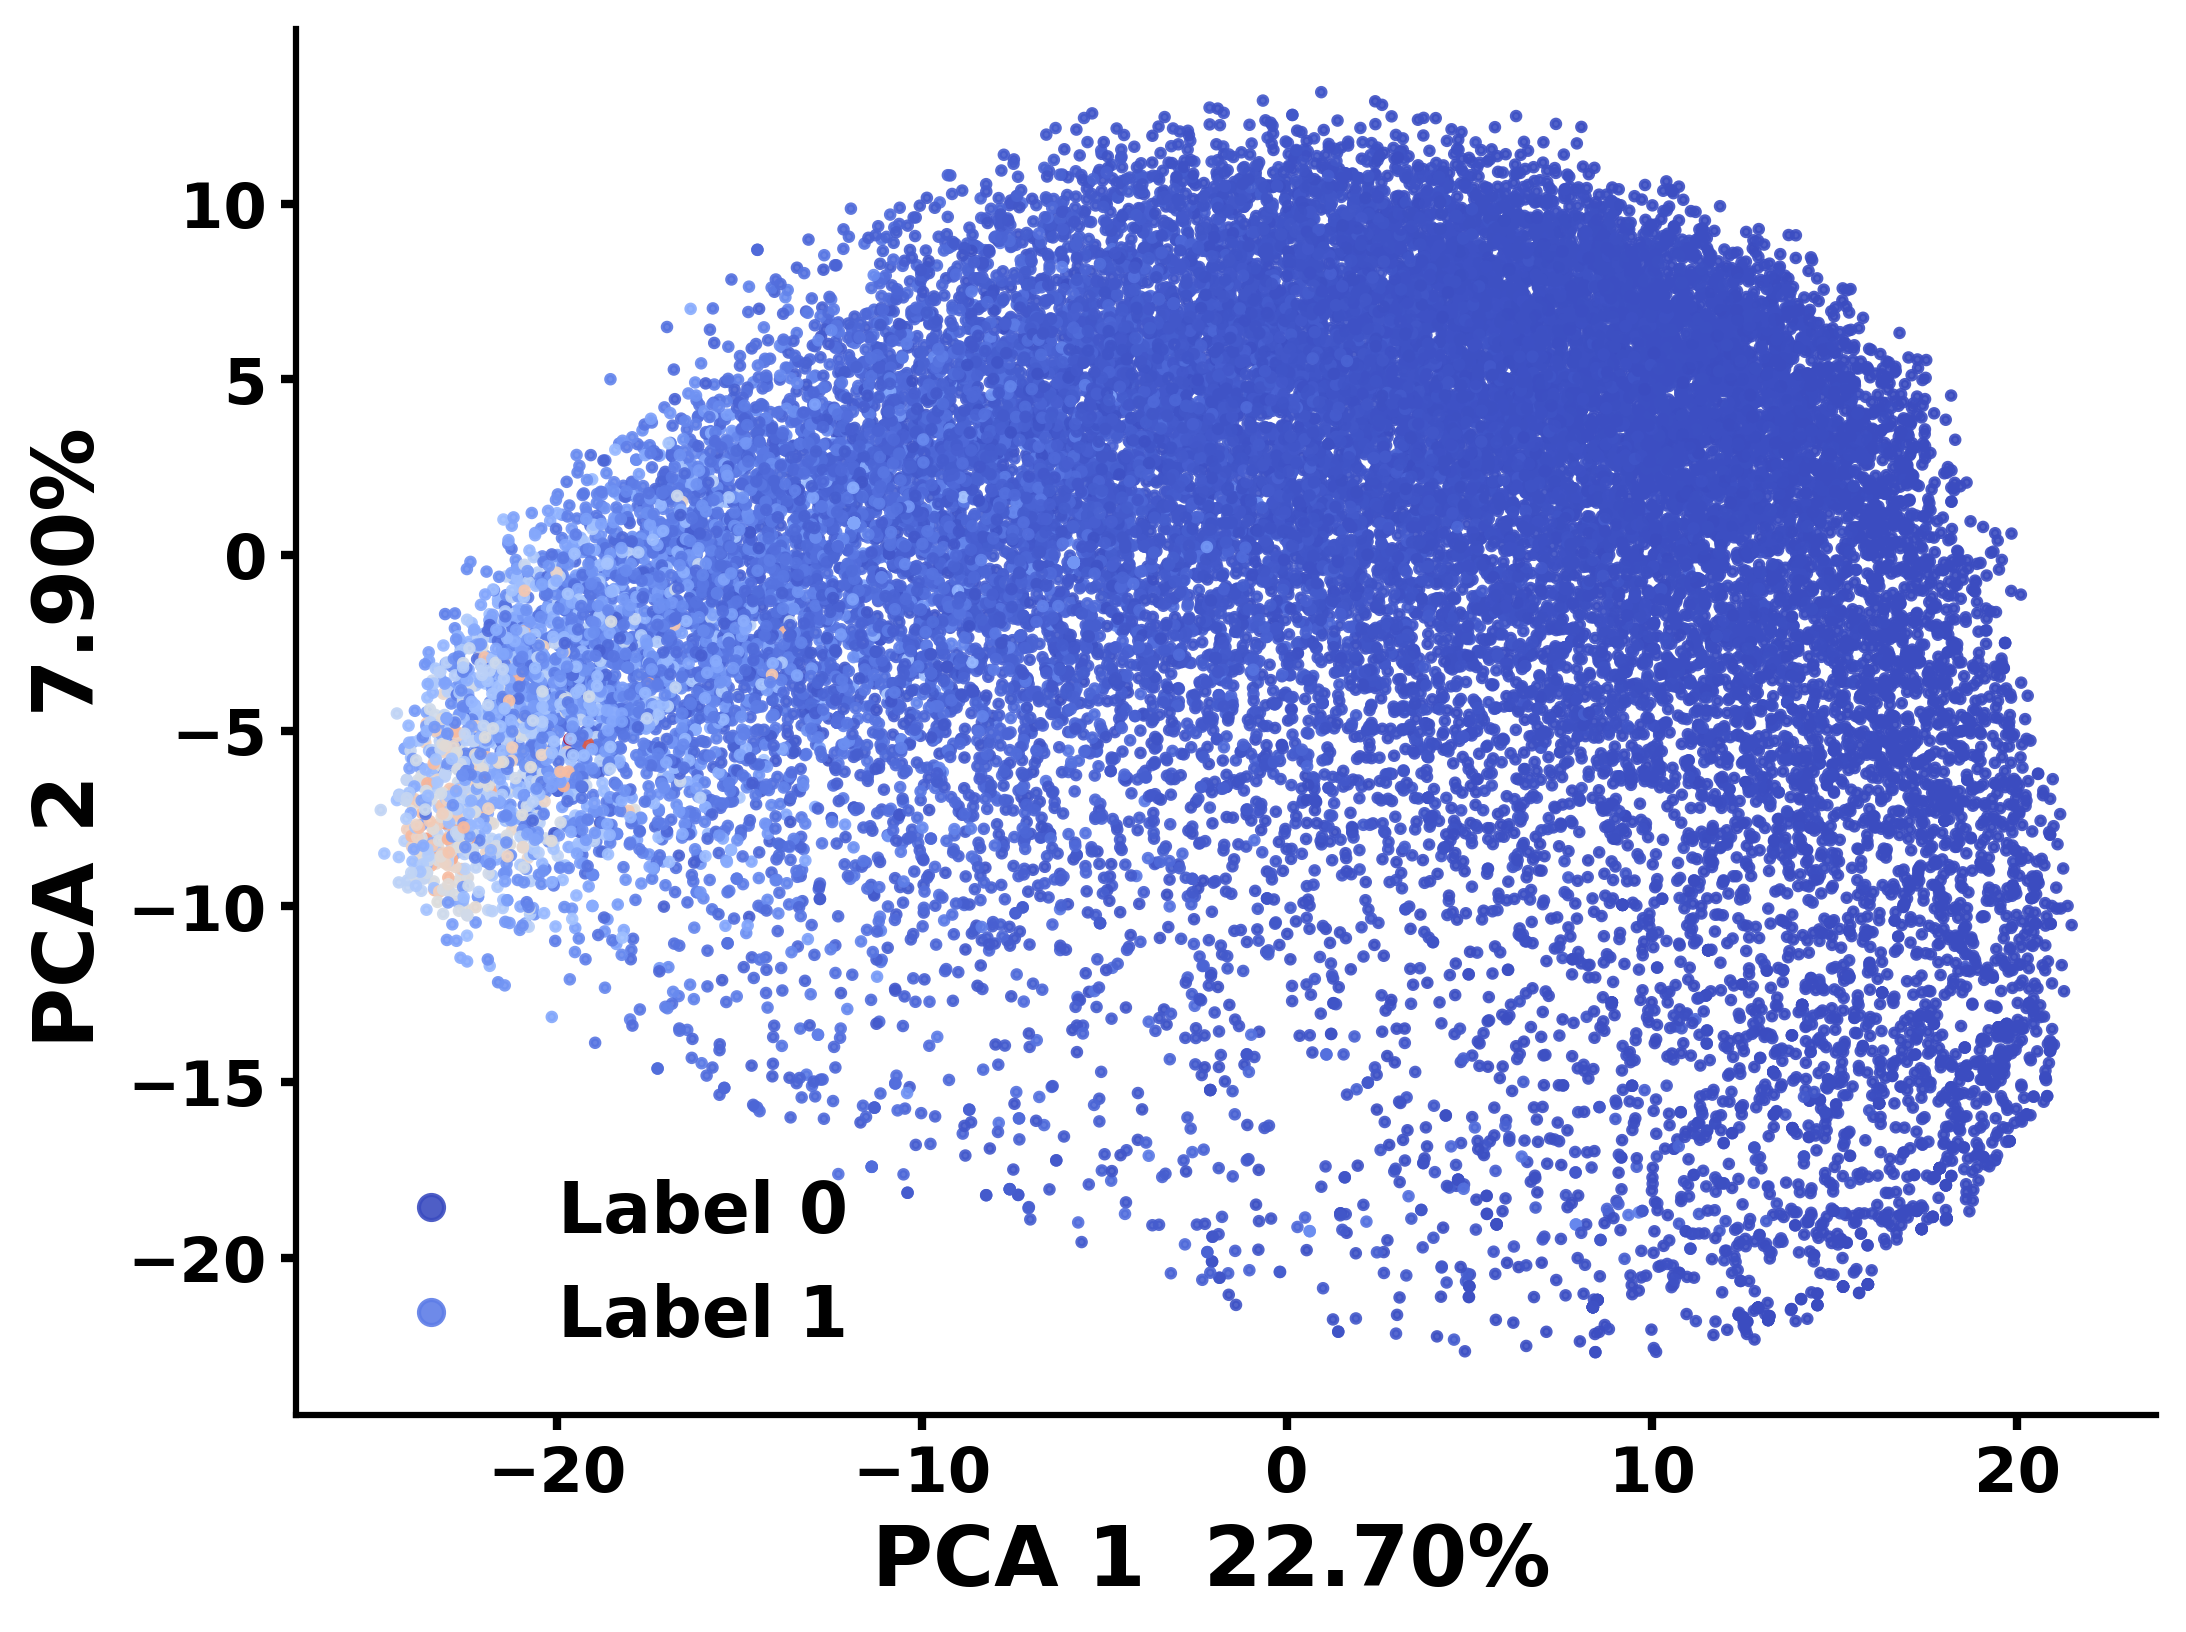

In [34]:



# 使用 PCA 降维，并获取解释方差
pca_result, explained_variance = apply_pca(IECSC_smiles_embeddings, n_components=2)

# 绘制 PCA 图，并显示每个主成分的解释方差百分比
plot_pca_with_variance(pca_result, y_mgL, explained_variance)

In [ ]:


# 使用 t-SNE 降维
tsne_result = apply_tsne(IECSC_smiles_embeddings, n_components=2)

# 绘制 t-SNE 图
plot_tsne_with_variance(tsne_result, y_mgL)